## 2.4 Runner类介绍

In [1]:
class Runner(object):
    def __init__(self, model, optimizer, loss_fn, metric):
        self.model = model  # 模型
        self.optimizer = optimizer  # 优化器
        self.loss_fn = loss_fn  # 损失函数
        self.metric = metric  # 评估指标

    # 模型训练
    def train(self, train_dataset, dev_dataset=None, **kwargs):
        pass

    # 模型评价
    def evaluate(self, data_set, **kwargs):
        pass

    # 模型预测
    def predict(self, x, **kwargs):
        pass
        
    # 模型保存
    def save_model(self, save_path):
        pass

    # 模型加载
    def load_model(self, model_path):
        pass

## 2.5 基于线性回归的波士顿房价预测
### 2.5.1 数据处理
#### 2.5.1.1 数据及介绍
<center>
  
| 字段名   | 类型 | 含义  |
| -------- | -------- | -------- | 
| CRIM	| float | 该镇的人均犯罪率 |
| ZN	| float |占地面积超过25,000平方呎的住宅用地比例|
| INDUS	| float |非零售商业用地比例|
| CHAS	| int   |是否邻近 Charles River 1=邻近；0=不邻近|
| NOX	| float |一氧化氮浓度  | 
| RM	| float |每栋房屋的平均客房数 |
| AGE	| float |1940年之前建成的自用单位比例 |
| DIS	| float |到波士顿5个就业中心的加权距离 |
| RAD	| int   |到径向公路的可达性指数 |
| TAX	| int   |全值财产税率  |
| PTRATIO|float | 学生与教师的比例 |
| LSTAT	| float |低收入人群占比 |
| MEDV	| float |同类房屋价格的中位数 |
  
  </center>
  <center>表2.1 波士顿房价字段含义</center>

In [2]:
import pandas as pd  # 开源数据分析和操作工具

# 利用pandas加载波士顿房价的数据集
data = pd.read_csv(r".\波士顿房价数据集\boston.csv")
# 预览前5行数据
data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PIRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


#### 2.5.1.2 数据清洗

In [3]:
# 查看各字段缺失值统计情况
data.isna().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PIRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

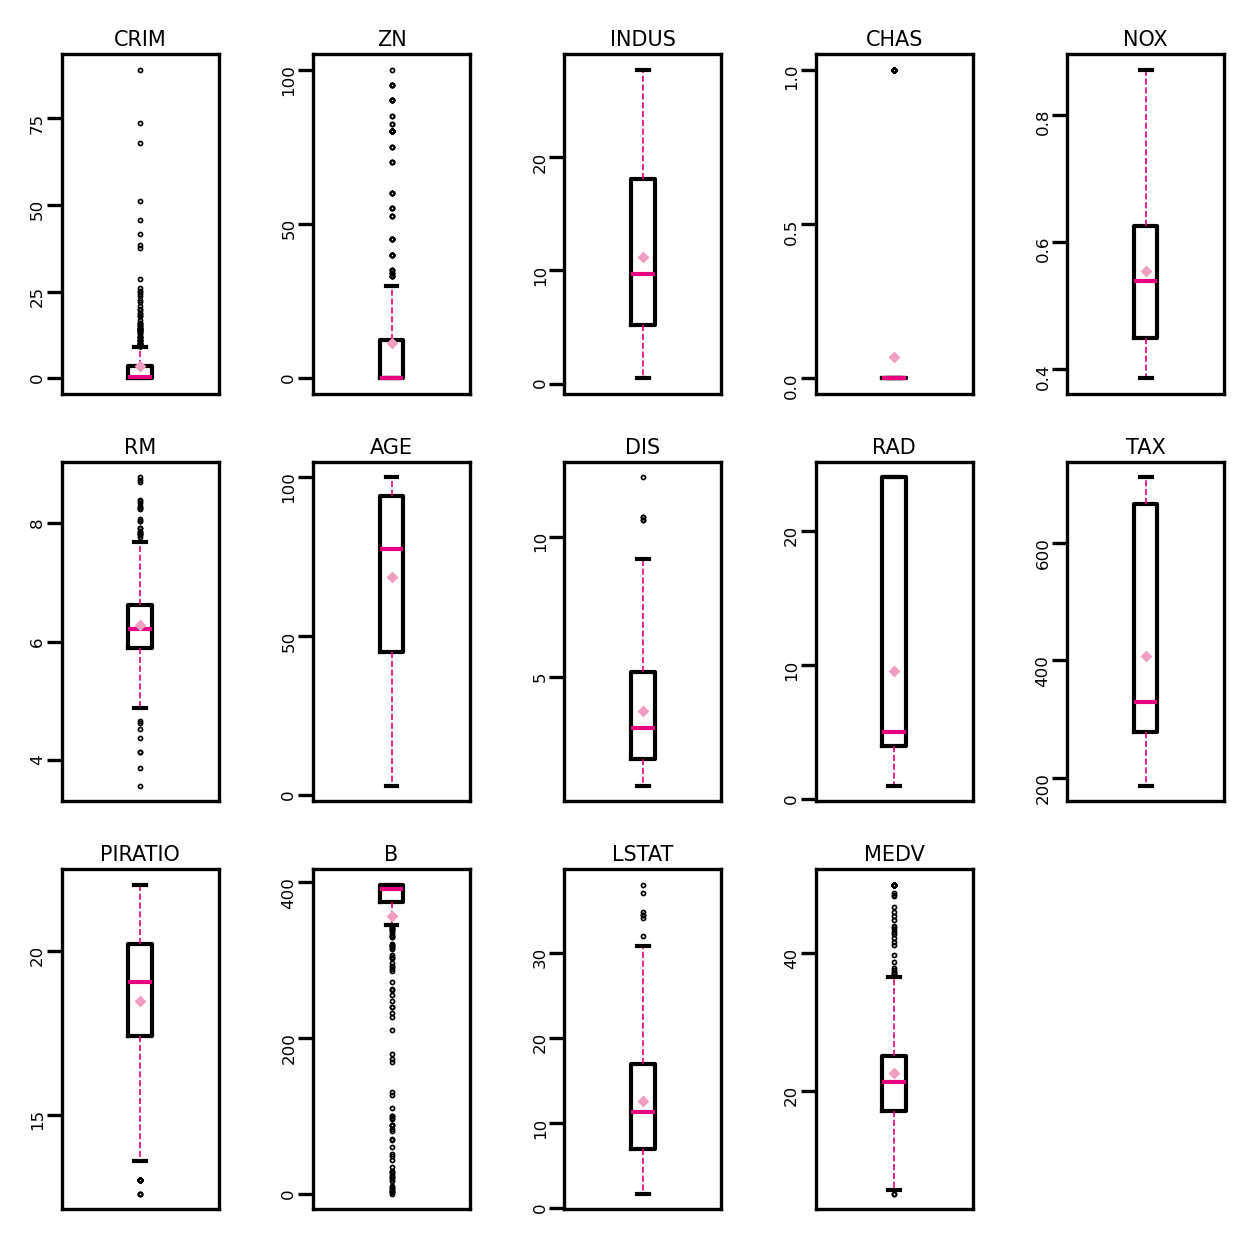

In [4]:
import matplotlib.pyplot as plt  # 可视化工具

# 箱线图查看异常值分布
def boxplot(data, fig_name, save_mode=0):
    # 绘制每个属性的箱线图
    data_col = list(data.columns)

    # 连续画几个图片
    plt.figure(figsize=(5,5), dpi=300)
    # 子图调整
    plt.subplots_adjust(wspace=0.6)
    # 每个特征画一个箱线图
    for i, col_name in enumerate(data_col):
        plt.subplot(3, 5, i+1)
        # 画箱线图
        plt.boxplot(data[col_name],
                   showmeans=True,
                   meanprops={"markersize":1, "marker":"D", "markeredgecolor":"#f19ec2"},  # 均值的属性
                   medianprops={"color":"#e4007f"},  # 中位数线的属性
                   whiskerprops={"color":"#e4007f", "linewidth":0.4, "linestyle":"--"},
                   flierprops={"markersize":0.4}
                   )
        # 图名
        plt.title(col_name, fontdict={"size":5}, pad=2)
        # y方向刻度
        plt.yticks(fontsize=4, rotation=90)
        plt.tick_params(pad=0.5)
        # x方向刻度
        plt.xticks([])
    if save_mode == 1:
        plt.savefig(fig_name)
    plt.show()

boxplot(data, "ml-vis5.pdf", 1)

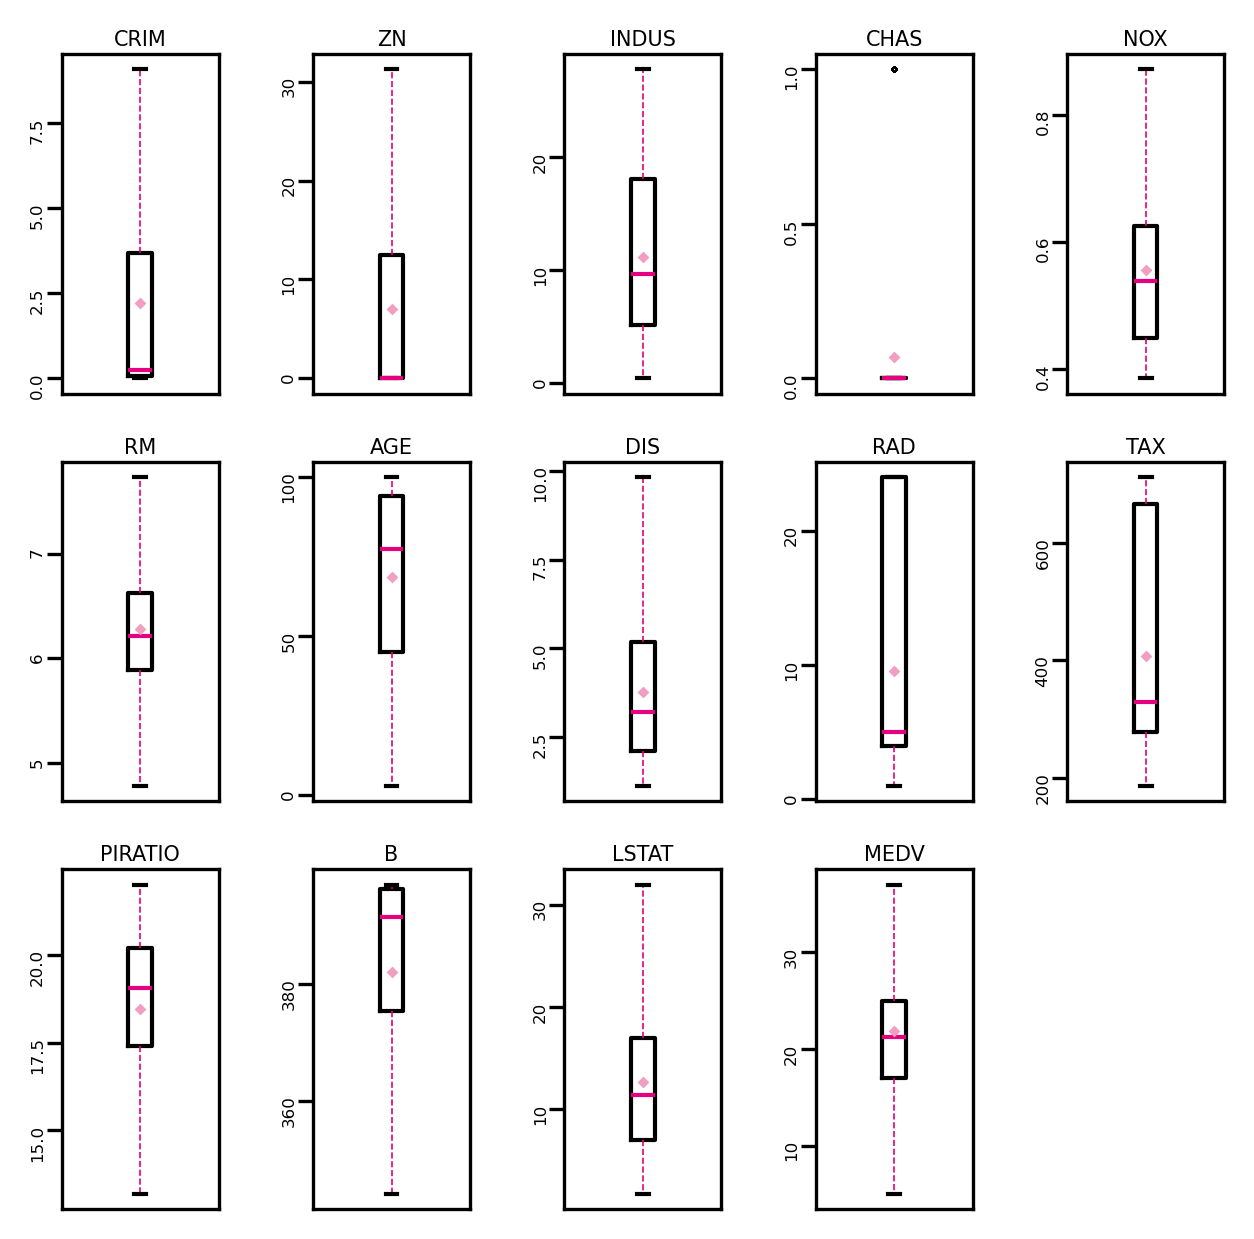

In [5]:
# 四分位处理异常值
num_features = data.select_dtypes(exclude=["object", "bool"]).columns.tolist()

for feature in num_features:
    if feature == "CHAS":
        continue

    Q1 = data[feature].quantile(q=0.25)  # 下四分位
    Q3 = data[feature].quantile(q=0.75)  # 上四分位

    IQR = Q3 - Q1
    top = Q3 + 1.5 * IQR  # 最大估计值
    bot = Q1 - 1.5 * IQR  # 最小估计值
    values = data[feature].values
    values[values > top] = top  # 临界值取代噪声
    values[values < bot] = bot  # 临界值取代噪声
    data[feature] = values.astype(data[feature].dtypes)

# 再次查看箱线图，异常值已被临界值替换(数据量较多或本身异常值较少时，箱线图展示会不容易体现出来)
boxplot(data, "ml-vis6.pdf", 1)

#### 2.5.1.3 数据集划分

In [6]:
import paddle

paddle.seed(10)

# 划分训练集和测试集
def train_test_split(X, y, train_percent=0.8):
    n = len(X)
    shuffled_indices = paddle.randperm(n)  # 返回一个数值在 0 到 n-1、随机排列的1-D Tensor
    train_set_size = int(n*train_percent)
    train_indices = shuffled_indices[:train_set_size]
    test_indices = shuffled_indices[train_set_size:]

    X = X.values
    y = y.values

    X_train = X[train_indices]
    y_train = y[train_indices]

    X_test = X[test_indices]
    y_test = y[test_indices]

    return X_train, X_test, y_train, y_test


X = data.drop(["MEDV"], axis=1)
y = data["MEDV"]

X_train, X_test, y_train, y_test = train_test_split(X, y)  # X_train每一行是个样本，shape[N, D]

#### 2.5.1.4 特征工程

In [7]:
import paddle

X_train = paddle.to_tensor(X_train, dtype="float32")
X_test = paddle.to_tensor(X_test, dtype="float32")
y_train = paddle.to_tensor(y_train, dtype="float32")
y_test = paddle.to_tensor(y_test, dtype="float32")

X_min = paddle.min(X_train, axis=0)
X_max = paddle.max(X_train, axis=0)

X_train = (X_train - X_min) / (X_max - X_min)
X_test = (X_test - X_min) / (X_max - X_min)

# 训练集构造
train_dataset = (X_train, y_train)
# 测试集构造
test_dataset = (X_test, y_test)

### 2.5.2 模型构建

In [8]:
from nndls.op import Linear

# 模型实例化
input_size = 13  # 输入有误，原为12, 应为13
model = Linear(input_size)

### 2.5.3 完善Runner类

In [9]:
import paddle.nn as nn
mse_loss = nn.MSELoss()

In [10]:
import paddle
import os
from nndls.optimizer import optimizer_lsm

class Runner(object):
    def __init__(self, model, optimizer, loss_fn, metric):
        # 优化器和损失函数为 None, 不再关注

        # 模型
        self.model = model
        # 评估指标
        self.metric = metric
        # 优化器
        self.optimizer = optimizer

    def train(self, dataset, reg_lambda, model_dir):
        X, y = dataset
        self.optimizer(self.model, X, y, reg_lambda)

        # 保存模型
        self.save_model(model_dir)

    def evaluate(self, dataset, **kwargs):
        X, y = dataset

        y_pred = self.model(X)
        result = self.metric(y_pred, y)

        return result

    def predict(self, X, **kwargs):
        return self.model(X)

    def save_model(self, model_dir):
        if not os.path.exists(model_dir):
            os.makedirs(model_dir)

        params_saved_path = os.path.join(model_dir, "params.pdtensor")
        paddle.save(model.params, params_saved_path)

    def load_model(self, model_dir):
        params_saved_path = os.path.join(model_dir, "params.pdtensor")
        self.model.params = paddle.load(params_saved_path)

optimizer = optimizer_lsm

# 实例化Runner
runner = Runner(model, optimizer=optimizer, loss_fn=None, metric=mse_loss)

### 2.5.4 模型训练

In [11]:
# 模型保存文件夹
saved_dir = r".\models"

# 启动训练
runner.train(train_dataset, reg_lambda=0, model_dir=saved_dir)

In [12]:
columns_list = data.columns.to_list()
weights = runner.model.params["w"].tolist()
b = runner.model.params["b"].item()

for i in range(len(weights)):
    print(columns_list[i], "weight:", weights[i])

print("b:", b)

CRIM weight: -4.703738689422607
ZN weight: 0.8968853950500488
INDUS weight: -0.814702033996582
CHAS weight: 1.3196687698364258
NOX weight: -5.554936408996582
RM weight: 7.892268657684326
AGE weight: -0.6289442777633667
DIS weight: -8.224712371826172
RAD weight: 7.482642650604248
TAX weight: -5.29121208190918
PIRATIO weight: -6.961075305938721
B weight: 0.21837005019187927
LSTAT weight: -15.579435348510742
b: 33.0284423828125


### 2.5.5 模型测试

In [13]:
# 加载模型权重
runner.load_model(saved_dir)

"""
x, y = test_dataset
print("x= \n" + x )
print("\n====\n") 
print("y= \n" + y)
"""

# print(model.input_size)

mse = runner.evaluate(test_dataset)
print("MSE: ", mse.item())

MSE:  11.342313766479492


### 2.5.6 模型预测

In [14]:
runner.load_model(saved_dir)
pred = runner.predict(X_test[:1])
print("真实房价: ", y_test[:1].item())
print("预测房价: ", pred.item())

真实房价:  36.962501525878906
预测房价:  33.884456634521484
